# Damped Oscillation Regression model

The model minimizes the mean squared error between predictions and observed data using a damped oscillation function defined as:

$$
y(x) = y_0 + A e^{-\lambda x} \cdot \cos(\omega x + \varphi)
$$

Where:

- $y_0$ represents the center of oscillations
- $A$ is the initial amplitude
- $\lambda$ controls the damping rate
- $\omega$ is the angular frequency
- $\varphi$ determines the phase shift

## Parameter stability through reparameterization

### Addressing gradient instability in the $\lambda$ parameter

The exponential term $e^{-\lambda x}$ creates a numerical challenge during optimization. Small changes in $\lambda$ can cause disproportionately large changes in the model output, leading to exploding gradients and unstable training.

To overcome this issue, we implement a parameter transformation. Instead of directly optimizing $\lambda$, we optimize an unconstrained parameter $\theta$ and derive $\lambda$ using the softplus function:

$$
\lambda = \operatorname{softplus}(\theta) = \ln(1 + e^{\theta})
$$

This reparameterization offers advantages:

- Ensures $\lambda$ remains strictly positive, reflecting the physical reality of damping
- Creates a more well-behaved gradient landscape
- Allows the optimizer to take appropriate step sizes for all parameters


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
def generate_synthetic_data() -> tuple[torch.Tensor, torch.Tensor]:
    y_0 = 0.5
    t = torch.linspace(0, 5, 200)
    A = 1.0
    lam = 0.8
    omega = 2.5
    phi = 0.5

    y = y_0 + A * torch.exp(-lam * t) * torch.cos(omega * t + phi)

    noise_level = 0.05
    y = y + torch.randn_like(y) * noise_level
    return t, y

In [3]:
class DampedOscillator(nn.Module):
    def __init__(
        self,
        y_0: float = 0.0,
        theta: float = 0.0,
        A: float = 0.5,
        omega: float = 1.0,
        phi: float = 0.0,
    ):
        super().__init__()
        # oscillation center
        self.y_0 = nn.Parameter(torch.tensor(y_0))
        # reparameterized lambda as (lambda = softplus(theta))
        self.theta = nn.Parameter(torch.tensor(theta))
        self.A = nn.Parameter(torch.tensor(A))
        # because we normalize time this omega is scaled
        self.omega = nn.Parameter(torch.tensor(omega))
        self.phi = nn.Parameter(torch.tensor(phi))

    def forward(self, t):
        lam = F.softplus(self.theta)
        return self.y_0 + self.A * torch.exp(-lam * t) * torch.cos(
            self.omega * t + self.phi
        )


def plot_fit_results(t_real, y, y_fit):
    """Plot the real data and fitted model.

    Args:
        t_real (torch.Tensor): Real time values
        y (torch.Tensor): Real data points
        y_fit (torch.Tensor): Fitted model predictions
    """
    plt.plot(t_real, y, ".", label="Real data", markersize=6)
    plt.plot(t_real, y_fit, label="Fitted model")
    plt.legend()
    plt.title("Fitting Noisy Damped Oscillation with Real-World Units")
    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [4]:
class Normalizer:
    range: torch.Tensor

    def __init__(self):
        self.min = torch.Tensor()
        self.max = torch.Tensor()
        self.range = torch.Tensor()

    def fit(self, x: torch.Tensor):
        self.min = x.min()
        self.max = x.max()
        self.range = self.max - self.min
        return self

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.min) / self.range

    def inverse_transform(self, x_scaled: torch.Tensor) -> torch.Tensor:
        return x_scaled * self.range + self.min

    def fit_transform(self, x: torch.Tensor) -> torch.Tensor:
        self.fit(x)
        return self.transform(x)

In [5]:
def fit_damped_oscillator(
    model: DampedOscillator,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    t_scaled: torch.Tensor,
    y: torch.Tensor,
    n_epochs: int = 10000,
    lr: float = 0.005,
) -> DampedOscillator:

    # Training loop
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        y_pred = model(t_scaled)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.5f}")

    return model


def recover_parameters(
    model: DampedOscillator, normalizer: Normalizer
) -> dict[str, float]:
    """
    Rescale back parameters that have been normalized
    """
    with torch.no_grad():
        lam_model = F.softplus(model.theta).item()
        omega_model = model.omega.item()

        T = normalizer.range.item()
        lam_real = lam_model / T
        omega_real = omega_model / T

        params = {
            "y_0": model.y_0.item(),
            "A": model.A.item(),
            "lambda": lam_real,
            "omega": omega_real,
            "phi": model.phi.item(),
        }
    return params


def print_parameters(params: dict[str, float]) -> None:
    print("\nFitted parameters (rescaled):")
    print(f"y_0    = {params['y_0']:.6f}")
    print(f"A      = {params['A']:.6f}")
    print(f"lambda = {params['lambda']:.6f} (real units)")
    print(f"omega  = {params['omega']:.6f} (real units)")
    print(f"phi    = {params['phi']:.6f}")

## Fit the syntetic data


Epoch 0, Loss: 0.09392
Epoch 100, Loss: 0.05274
Epoch 200, Loss: 0.05268
Epoch 300, Loss: 0.05266
Epoch 400, Loss: 0.05265
Epoch 500, Loss: 0.05264
Epoch 600, Loss: 0.05264
Epoch 700, Loss: 0.05263
Epoch 800, Loss: 0.05262
Epoch 900, Loss: 0.05261
Epoch 1000, Loss: 0.05251
Epoch 1100, Loss: 0.04376
Epoch 1200, Loss: 0.00946
Epoch 1300, Loss: 0.00434
Epoch 1400, Loss: 0.00239
Epoch 1500, Loss: 0.00239
Epoch 1600, Loss: 0.00239
Epoch 1700, Loss: 0.00239
Epoch 1800, Loss: 0.00239
Epoch 1900, Loss: 0.00239
Epoch 2000, Loss: 0.00239
Epoch 2100, Loss: 0.00239
Epoch 2200, Loss: 0.00239
Epoch 2300, Loss: 0.00239
Epoch 2400, Loss: 0.00239
Epoch 2500, Loss: 0.00239
Epoch 2600, Loss: 0.00239
Epoch 2700, Loss: 0.00239
Epoch 2800, Loss: 0.00239
Epoch 2900, Loss: 0.00239
Epoch 3000, Loss: 0.00239
Epoch 3100, Loss: 0.00239
Epoch 3200, Loss: 0.00239
Epoch 3300, Loss: 0.00239
Epoch 3400, Loss: 0.00239
Epoch 3500, Loss: 0.00239
Epoch 3600, Loss: 0.00239
Epoch 3700, Loss: 0.00239
Epoch 3800, Loss: 0.0023

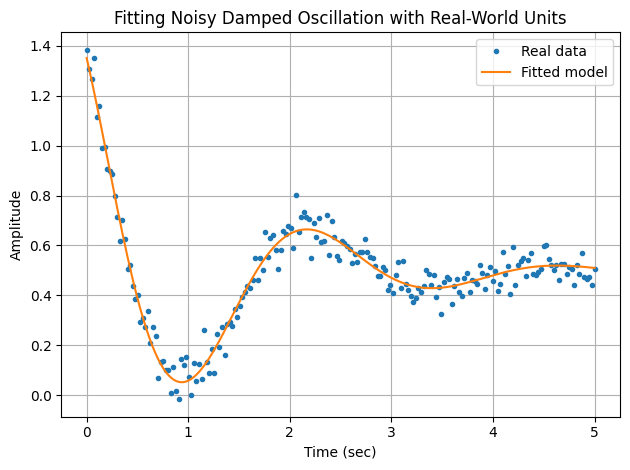

In [6]:
# generate data
t_real, y = generate_synthetic_data()

# normalize
normalizer = Normalizer()
t_scaled = normalizer.fit_transform(t_real)

# define model and optimizer
model = DampedOscillator()
optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

# fit data
model = fit_damped_oscillator(model, optimizer, loss_fn, t_scaled, y)
y_fit = model(t_scaled).detach()

# rescale back the parameters
params = recover_parameters(model, normalizer)
print_parameters(params)

# Plot results
plot_fit_results(t_real, y, y_fit)

## Fit real data


In [7]:
# fmt: off
y1 = torch.tensor([
    10, 5, 5, 5, 5, 10, 15, 20, 25, 30, 40, 40, 45, 45, 45, 40, 40, 35, 30, 25, 20, 20, 15, 15, 15, 20, 20, 20, 25, 30, 30,
    35, 35, 35, 40, 35, 35, 35, 30, 30, 25, 20, 20, 20, 20, 20, 20, 20, 25, 25, 25, 30, 30, 30, 30, 35, 30, 30, 30, 30, 25
], dtype=torch.float32)

y2 = torch.tensor([
    30, 35, 45, 55, 60, 70, 80, 75, 60, 50, 35, 30, 25, 25, 30, 40, 45, 55, 70, 80, 80, 75, 70, 65, 60, 55, 55, 50, 50, 50, 55,
    55, 60, 65, 70, 70, 75, 75, 75, 75, 75, 70, 70, 65, 65, 60, 60, 60, 55, 55, 55, 60, 60, 65, 65, 65, 70, 70, 70, 70, 70
], dtype=torch.float32)

# X = torch.tensor(list(range(0, 1830, 30)))
X = torch.linspace(0, 1830, 61)

# fmt: on

Epoch 0, Loss: 769.09418
Epoch 100, Loss: 361.30505
Epoch 200, Loss: 181.80449
Epoch 300, Loss: 120.36317
Epoch 400, Loss: 104.57712
Epoch 500, Loss: 95.73916
Epoch 600, Loss: 90.85176
Epoch 700, Loss: 89.18889
Epoch 800, Loss: 88.67039
Epoch 900, Loss: 88.52371
Epoch 1000, Loss: 88.48537
Epoch 1100, Loss: 88.47489
Epoch 1200, Loss: 88.47054
Epoch 1300, Loss: 88.46722
Epoch 1400, Loss: 88.46389
Epoch 1500, Loss: 88.46036
Epoch 1600, Loss: 88.45664
Epoch 1700, Loss: 88.45264
Epoch 1800, Loss: 88.44840
Epoch 1900, Loss: 88.44388
Epoch 2000, Loss: 88.43903
Epoch 2100, Loss: 88.43387
Epoch 2200, Loss: 88.42829
Epoch 2300, Loss: 88.42224
Epoch 2400, Loss: 88.41557
Epoch 2500, Loss: 88.40810
Epoch 2600, Loss: 88.39941
Epoch 2700, Loss: 88.38865
Epoch 2800, Loss: 88.37374
Epoch 2900, Loss: 88.34808
Epoch 3000, Loss: 88.27941
Epoch 3100, Loss: 88.03137
Epoch 3200, Loss: 87.63903
Epoch 3300, Loss: 87.14539
Epoch 3400, Loss: 86.60508
Epoch 3500, Loss: 85.98536
Epoch 3600, Loss: 85.25180
Epoch 37

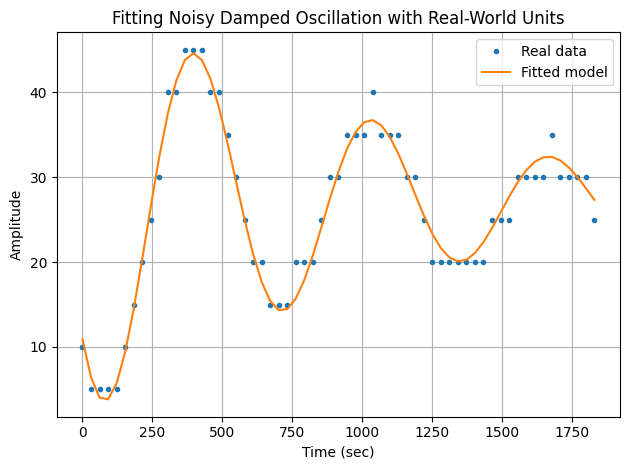

In [14]:
# normalize
normalizer = Normalizer()
X_scaled = normalizer.fit_transform(X)

# define model and optimizer
model = DampedOscillator()
optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

# fit data
model = fit_damped_oscillator(model, optimizer, loss_fn, X_scaled, y1)
y_fit = model(X_scaled).detach()

# rescale back the parameters
params = recover_parameters(model, normalizer)
print_parameters(params)
# Plot results
plot_fit_results(X, y1, y_fit)

In [9]:
print(params)
T = 2 * torch.pi / params["omega"]
print(T)

{'y_0': 0.49549782276153564, 'A': 0.9541326761245728, 'lambda': 0.002120147116197263, 'omega': -0.006972690749038113, 'phi': -0.45762014389038086}
-901.1134343002886


In [29]:
# normalize
y2_clipped = y2[20:]
X_clipped = X[20:]
# X_clipped = X
# y2_clipped = y2
normalizer = Normalizer()
X_scaled = normalizer.fit_transform(X_clipped)

# define model and optimizer
# y_0=63.75,
# lam=0.0012,
# A=50,
# T=630,
# time=time,
# phi=np.pi * 0.85,
model = DampedOscillator(
    y_0=63.75,
    A=50.0,
    omega=0.009903,
    phi=torch.pi * 0.85,
)
optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

# fit data
model = fit_damped_oscillator(model, optimizer, loss_fn, X_scaled, y2_clipped)

Epoch 0, Loss: 1178.04395
Epoch 100, Loss: 64.13230
Epoch 200, Loss: 63.53937
Epoch 300, Loss: 63.50842
Epoch 400, Loss: 63.47343
Epoch 500, Loss: 63.43542
Epoch 600, Loss: 63.39458
Epoch 700, Loss: 63.35031
Epoch 800, Loss: 63.30090
Epoch 900, Loss: 63.24308
Epoch 1000, Loss: 63.17057
Epoch 1100, Loss: 63.07138
Epoch 1200, Loss: 62.92103
Epoch 1300, Loss: 62.66669
Epoch 1400, Loss: 62.19315
Epoch 1500, Loss: 61.29234
Epoch 1600, Loss: 59.82396
Epoch 1700, Loss: 58.03314
Epoch 1800, Loss: 55.97934
Epoch 1900, Loss: 53.17993
Epoch 2000, Loss: 49.61045
Epoch 2100, Loss: 45.91380
Epoch 2200, Loss: 42.61049
Epoch 2300, Loss: 39.85449
Epoch 2400, Loss: 37.61756
Epoch 2500, Loss: 35.81659
Epoch 2600, Loss: 34.34330
Epoch 2700, Loss: 33.05348
Epoch 2800, Loss: 31.74577
Epoch 2900, Loss: 30.12494
Epoch 3000, Loss: 27.70408
Epoch 3100, Loss: 23.61133
Epoch 3200, Loss: 17.07533
Epoch 3300, Loss: 9.90488
Epoch 3400, Loss: 4.92764
Epoch 3500, Loss: 2.64070
Epoch 3600, Loss: 1.90851
Epoch 3700, Los


Fitted parameters (rescaled):
y_0    = 64.818626
A      = 18.489605
lambda = 0.000948 (real units)
omega  = 0.010025 (real units)
phi    = 0.658554


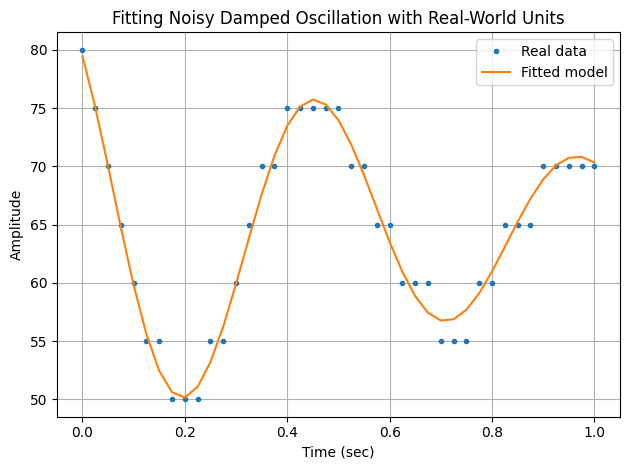

In [30]:
# rescale back the parameters
params = recover_parameters(model, normalizer)
print_parameters(params)

# Plot results
y_fit = model(X_scaled).detach()
plot_fit_results(X_scaled, y2_clipped, y_fit)

In [31]:
print(params)
T = 2 * torch.pi / params["omega"]
print(T)

{'y_0': 64.8186264038086, 'A': 18.489604949951172, 'lambda': 0.000947718053567605, 'omega': 0.010025413700791656, 'phi': 0.6585540771484375}
626.7257885510934
